In [2]:
!pip install kaggle -q
!kaggle datasets download -d sgpjesus/bank-account-fraud-dataset-neurips-2022
!unzip -q bank-account-fraud-dataset-neurips-2022.zip -d bank_fraud

Dataset URL: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022
License(s): CC-BY-NC-SA-4.0
Resuming from 50331648 bytes (507722516 bytes left)...
100% 532M/532M [00:02<00:00, 171MB/s]



In [3]:
import pandas as pd

df = pd.read_csv("bank_fraud/Base.csv")
print(df.shape)
print(df["fraud_bool"].value_counts(normalize=True))


(1000000, 32)
fraud_bool
0    0.988971
1    0.011029
Name: proportion, dtype: float64


MarkDown Cells

In [4]:
df.shape

(1000000, 32)

In [5]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [6]:
df.sample(5)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
709915,0,0.2,0.392231,-1,248,30,0.014572,-0.961677,AB,711,...,0,1500.0,0,INTERNET,0.441904,macintosh,1,1,0,5
702219,0,0.6,0.284015,-1,349,50,0.003005,-1.278358,AC,2611,...,0,1000.0,0,INTERNET,1.294009,other,1,1,0,5
962073,0,0.7,0.664640,-1,121,40,0.004205,-0.957595,AB,396,...,0,990.0,0,INTERNET,3.985434,other,0,1,0,7
884507,1,0.5,0.169384,-1,189,30,0.002153,-0.918993,AD,2472,...,0,1000.0,0,INTERNET,20.446827,linux,1,2,0,6
217466,0,0.2,0.529502,12,0,20,0.010541,-0.817030,AB,712,...,0,200.0,0,INTERNET,4.386528,linux,1,1,0,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [8]:
# check every numeric column for suspiciously common -1 values
# a real missing-value flag will show up as a big spike at exactly -1

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    count_negative_one = (df[col] == -1).sum()
    if count_negative_one > 0:
        pct = count_negative_one / len(df) * 100
        print(f"{col}: {count_negative_one} rows ({pct:.2f}%)")

prev_address_months_count: 712920 rows (71.29%)
current_address_months_count: 4254 rows (0.43%)
credit_risk_score: 488 rows (0.05%)
bank_months_count: 253635 rows (25.36%)
session_length_in_minutes: 2015 rows (0.20%)
device_distinct_emails_8w: 359 rows (0.04%)


In [9]:
df["credit_risk_score"].describe()

,credit_risk_score
count,1000000.000000
mean,130.989595
std,69.681812
min,-170.000000
25%,83.000000
50%,122.000000
75%,178.000000
max,389.000000


"Checked all numeric columns for -1 values. Excluded credit_risk_score from the missing-value fix — its distribution (-170 to 389) shows -1 falls naturally within a continuous range rather than being an outlier placeholder, confirmed via .describe()."

In [10]:
missing_flag_cols = ["prev_address_months_count", "current_address_months_count",
                      "bank_months_count", "session_length_in_minutes",
                      "device_distinct_emails_8w"]

In [11]:
import numpy as np

for col in missing_flag_cols:
    df[col] = df[col].replace(-1, np.nan)

df[missing_flag_cols].isnull().sum()

,0
prev_address_months_count,712920
current_address_months_count,4254
bank_months_count,253635
session_length_in_minutes,2015
device_distinct_emails_8w,359


In [12]:
# create explicit "was this missing" flags before we do anything else
# this lets us test in EDA whether missingness itself predicts fraud

for col in missing_flag_cols:
    df[col + "_was_missing"] = df[col].isnull().astype(int)

df[[c for c in df.columns if "_was_missing" in c]].sum()

,0
prev_address_months_count_was_missing,712920
current_address_months_count_was_missing,4254
bank_months_count_was_missing,253635
session_length_in_minutes_was_missing,2015
device_distinct_emails_8w_was_missing,359


In [13]:
df["fraud_bool"].value_counts()

,count
fraud_bool,
0,988971
1,11029


In [14]:
df["fraud_bool"].value_counts(normalize=True) * 100

,proportion
fraud_bool,
0,98.8971
1,1.1029


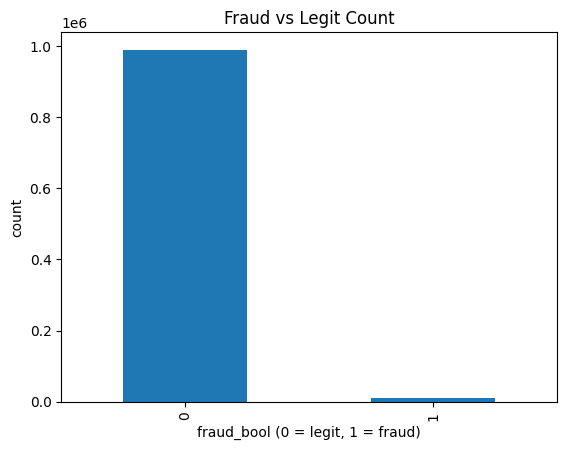

In [15]:
import matplotlib.pyplot as plt

df["fraud_bool"].value_counts().plot(kind="bar")
plt.title("Fraud vs Legit Count")
plt.xlabel("fraud_bool (0 = legit, 1 = fraud)")
plt.ylabel("count")
plt.show()

"Fraud cases make up only ~1.1% of the data (~11,000 out of 1M rows). This severe imbalance means accuracy is not a usable metric — a model predicting 'legit' for everything would score ~99% accuracy while catching zero fraud. PR-AUC and recall-focused threshold selection will be used instead.





In [16]:
df.groupby("payment_type")["fraud_bool"].mean().sort_values(ascending=False)

,fraud_bool
payment_type,
AC,0.016698
AB,0.011251
AD,0.010822
AA,0.005282
AE,0.003460


In [17]:
df.groupby("source")["fraud_bool"].mean().sort_values(ascending=False)

,fraud_bool
source,
TELEAPP,0.015891
INTERNET,0.010994


In [18]:
monthly_fraud = df.groupby("month")["fraud_bool"].mean()
monthly_fraud

,fraud_bool
month,
0,0.011326
1,0.009387
2,0.008746
3,0.009222
4,0.011371
5,0.011825
6,0.013405
7,0.014746


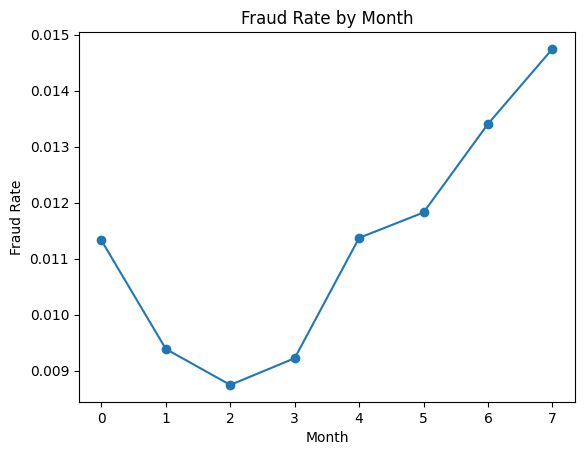

In [19]:
monthly_fraud.plot(kind="line", marker="o")
plt.title("Fraud Rate by Month")
plt.xlabel("Month")
plt.ylabel("Fraud Rate")
plt.show()

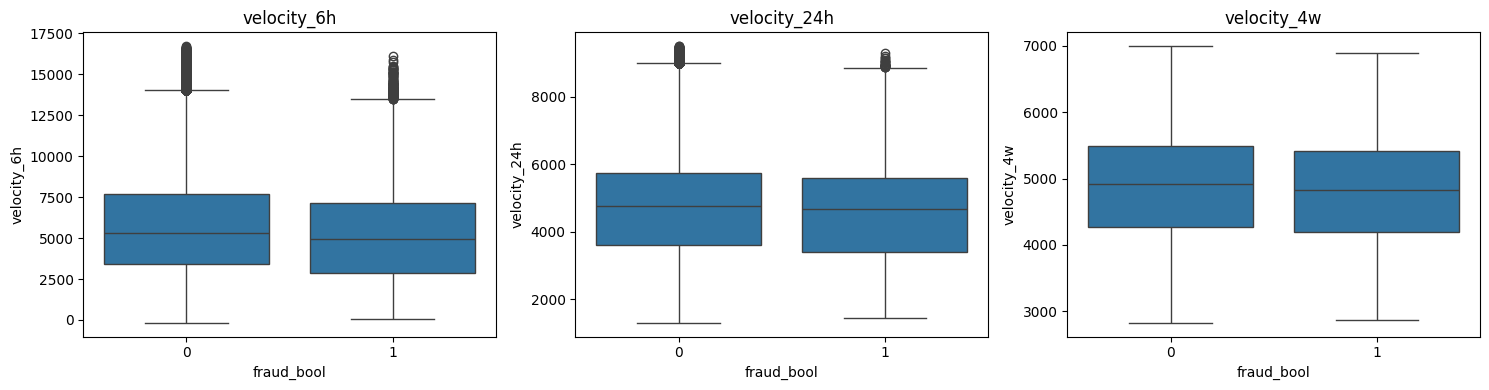

In [20]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(["velocity_6h", "velocity_24h", "velocity_4w"]):
    sns.boxplot(data=df, x="fraud_bool", y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

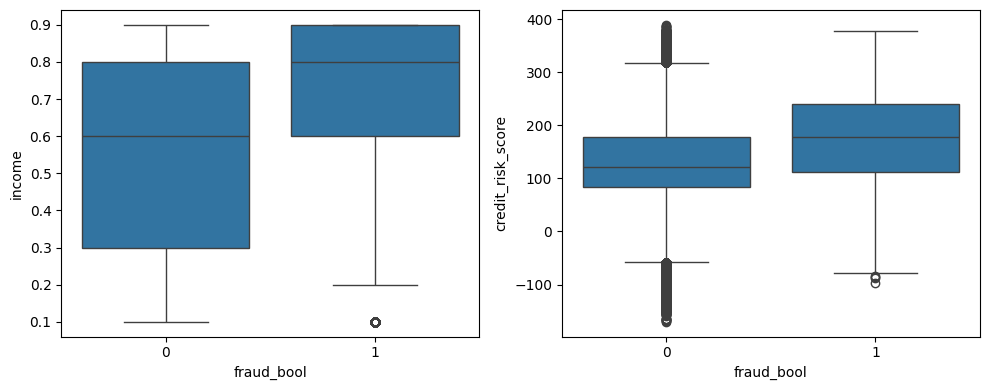

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x="fraud_bool", y="income", ax=axes[0])
sns.boxplot(data=df, x="fraud_bool", y="credit_risk_score", ax=axes[1])
plt.tight_layout()
plt.show()

In [22]:
for col in ["prev_address_months_count_was_missing", "bank_months_count_was_missing"]:
    print(col)
    print(df.groupby(col)["fraud_bool"].mean())
    print()

prev_address_months_count_was_missing
prev_address_months_count_was_missing
0    0.003118
1    0.014215
Name: fraud_bool, dtype: float64

bank_months_count_was_missing
bank_months_count_was_missing
0    0.009230
1    0.016323
Name: fraud_bool, dtype: float64



Missingness itself turned out to be predictive: applicants missing previous address history show a 4.5x higher fraud rate (1.42% vs 0.31%), and those missing bank account history show a 1.8x higher rate (1.63% vs 0.92%). This confirms the _was_missing flags engineered earlier aren't just handling NaNs technically — they capture a real risk signal that the model should be able to use."



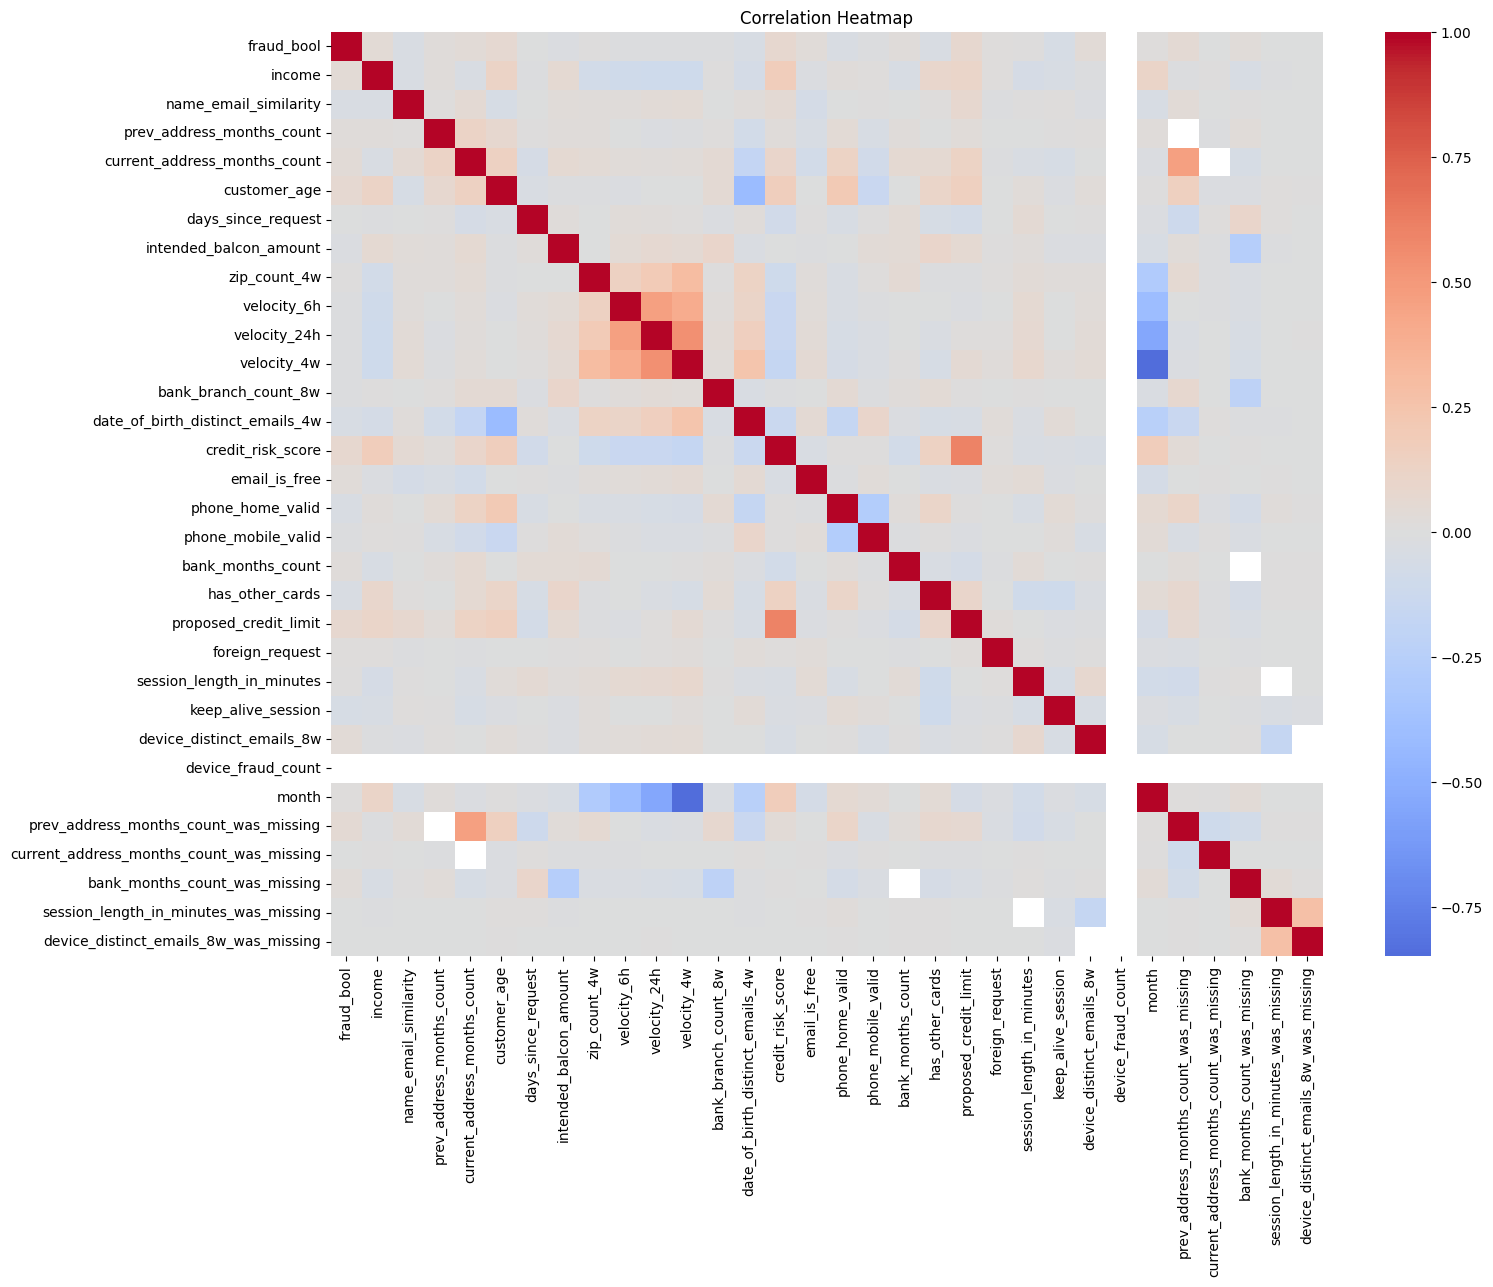

In [23]:
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Key findings from EDA: fraud shows a clear behavioral fingerprint — elevated application velocity, missing identity/history signals (previous address, bank tenure), and [whatever you find in payment_type/source/velocity once you run those]. These patterns motivate feature choices going into modeling, and the temporal month trend confirms fraud behavior is not static — reinforcing the decision to split by time rather than randomly."

In [24]:
df["month"].value_counts().sort_index()

,count
month,
0,132440
1,127620
2,136979
3,150936
4,127691
5,119323
6,108168
7,96843


In [25]:
train_df = df[df["month"] <= 5].copy()
test_df = df[df["month"] >= 6].copy()

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("train fraud rate:", train_df["fraud_bool"].mean())
print("test fraud rate:", test_df["fraud_bool"].mean())

train shape: (794989, 37)
test shape: (205011, 37)
train fraud rate: 0.010252972053701372
test fraud rate: 0.014038271117159567


Split by month rather than randomly — trained on months 0–5, tested on months 6–7. This mirrors real deployment, where a fraud model only ever has access to past data when scoring new applications, and avoids inflating performance by letting the model 'see' future patterns during training."

Preprocessing

In [26]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["payment_type", "employment_status", "housing_status", "source", "device_os"]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    encoders[col] = le

train_df[categorical_cols].head()

,payment_type,employment_status,housing_status,source,device_os
0,0,1,2,0,0
1,3,0,2,0,2
2,1,0,2,0,3
3,1,0,2,0,0
4,0,0,2,0,2


In [27]:
for col in categorical_cols:
    le = encoders[col]
    known_categories = set(le.classes_)

    # any category in test that wasn't seen during training gets treated as "unknown"
    unseen_count = (~test_df[col].isin(known_categories)).sum()
    print(col, "-> unseen categories in test:", unseen_count)

payment_type -> unseen categories in test: 0
employment_status -> unseen categories in test: 0
housing_status -> unseen categories in test: 0
source -> unseen categories in test: 0
device_os -> unseen categories in test: 0


In [28]:
for col in categorical_cols:
    le = encoders[col]
    known_categories = set(le.classes_)

    test_df[col] = test_df[col].apply(lambda x: x if x in known_categories else le.classes_[0])
    test_df[col] = le.transform(test_df[col])

test_df[categorical_cols].head()

,payment_type,employment_status,housing_status,source,device_os
794989,0,0,2,0,2
794990,2,5,1,0,0
794991,1,0,1,0,0
794992,1,0,0,0,2
794993,2,3,1,0,0


In [29]:
feature_cols = [c for c in train_df.columns if c not in ["fraud_bool", "month"]]

X_train = train_df[feature_cols]
y_train = train_df["fraud_bool"]

X_test = test_df[feature_cols]
y_test = test_df["fraud_bool"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (794989, 35)
X_test: (205011, 35)


MODEL TRANING

In [30]:
from xgboost import XGBClassifier

baseline_model = XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42
)

baseline_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", ratio)

scale_pos_weight: 96.53269537480064


In [32]:
model = XGBClassifier(
    scale_pos_weight=ratio,
    max_depth=5,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

MODEL EVALUATION

In [33]:
from sklearn.metrics import average_precision_score

baseline_probs = baseline_model.predict_proba(X_test)[:, 1]
model_probs = model.predict_proba(X_test)[:, 1]

baseline_pr_auc = average_precision_score(y_test, baseline_probs)
model_pr_auc = average_precision_score(y_test, model_probs)

print("Baseline PR-AUC:", baseline_pr_auc)
print("Imbalance-aware PR-AUC:", model_pr_auc)

Baseline PR-AUC: 0.18986860297622285
Imbalance-aware PR-AUC: 0.18021216272975185


In [34]:
from sklearn.metrics import classification_report

# Define chosen_threshold. This value would typically be determined through model evaluation (e.g., using a PR curve).
chosen_threshold = 0.5  # Placeholder value, adjust as needed

y_pred = (model_probs >= chosen_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

              precision    recall  f1-score   support

       Legit       1.00      0.85      0.92    202133
       Fraud       0.07      0.76      0.12      2878

    accuracy                           0.85    205011
   macro avg       0.53      0.80      0.52    205011
weighted avg       0.98      0.85      0.90    205011



Contrary to expectation, scale_pos_weight slightly reduced PR-AUC (0.180 vs 0.190 baseline). This suggests that on this dataset's scale (~795K training rows), XGBoost already learns the minority class pattern effectively without reweighting, and the adjustment instead skews probability calibration rather than improving ranking. Proceeding with the baseline (unweighted) model going into hyperparameter tuning."

In [35]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, baseline_probs)

target_recall = 0.80
valid_idx = np.where(recall >= target_recall)[0]
best_idx = valid_idx[np.argmax(precision[valid_idx])]
chosen_threshold = thresholds[min(best_idx, len(thresholds) - 1)]

print("Chosen threshold:", chosen_threshold)
print("precision:", precision[best_idx],
      "\nrecall:", recall[best_idx])

y_pred = (baseline_probs >= chosen_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

Chosen threshold: 0.011686173
precision: 0.061712846347607056 
recall: 0.8002084781097984
              precision    recall  f1-score   support

       Legit       1.00      0.83      0.90    202133
       Fraud       0.06      0.80      0.11      2878

    accuracy                           0.83    205011
   macro avg       0.53      0.81      0.51    205011
weighted avg       0.98      0.83      0.89    205011



"Overall accuracy dropped to 83% compared to a naive 99% baseline (predicting 'no fraud' for everyone) — but that 99% baseline catches zero fraud. This confirms accuracy is the wrong metric for this problem, and the tradeoff toward higher recall (80%) at the cost of precision (6%) is intentional, aligned with a real fraud workflow where flagged cases get reviewed by a human before any action is taken."



HYPER PARAMETER TUNNING

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300, 500],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [37]:
search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=15,              # try 15 random combinations
    scoring="average_precision",  # this is PR-AUC
    cv=3,                   # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=2)

In [38]:
print("Best parameters:", search.best_params_)
print("Best CV PR-AUC:", search.best_score_)

Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.15301612001578868


In [39]:
best_model = search.best_estimator_

tuned_probs = best_model.predict_proba(X_test)[:, 1]
tuned_pr_auc = average_precision_score(y_test, tuned_probs)

print("Baseline PR-AUC:", baseline_pr_auc)
print("Tuned PR-AUC (on real holdout):", tuned_pr_auc)

Baseline PR-AUC: 0.18986860297622285
Tuned PR-AUC (on real holdout): 0.19119804583107158


"Hyperparameter tuning improved PR-AUC marginally (0.1902 baseline → 0.1912 tuned) — a modest gain of about 0.6%. This suggests the baseline configuration was already reasonably well-suited to this problem, and the model is more limited by the inherent signal in the features than by hyperparameter choice at this point."

SHAP

In [40]:
!pip install shap -q

In [41]:
import shap

explainer = shap.TreeExplainer(baseline_model)

# just test on a small batch first (SHAP can be slow on the full test set)
sample = X_test.iloc[:100]
shap_values = explainer.shap_values(sample)

shap_values.shape

(100, 35)

In [42]:
# quick sanity check — visualize what's driving one specific flagged transaction
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], sample.iloc[0])

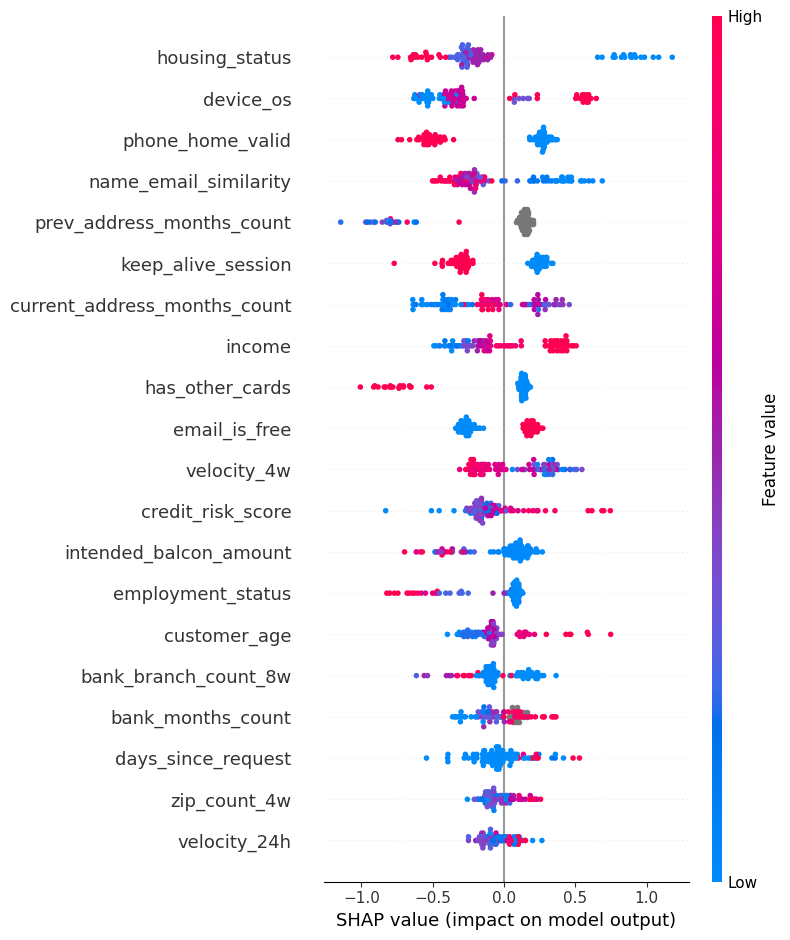

In [43]:
# global view — which features matter most overall across these 100 rows
shap.summary_plot(shap_values, sample)

 Finalize + Save

In [44]:
final_model = search.best_estimator_

# recompute threshold specifically for this model (not reusing baseline's threshold)
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, tuned_probs)

target_recall = 0.80
valid_idx = np.where(recall >= target_recall)[0]
best_idx = valid_idx[np.argmax(precision[valid_idx])]
final_threshold = thresholds[min(best_idx, len(thresholds) - 1)]

print("Final threshold:", final_threshold)
print("Precision:", precision[best_idx], "Recall:", recall[best_idx])

Final threshold: 0.012337303
Precision: 0.061870619511802144 Recall: 0.8005559416261293


In [45]:
import joblib

joblib.dump(final_model, "fraud_model_final.joblib")

['fraud_model_final.joblib']

In [46]:
# save the SHAP explainer too — copilot will need this to explain live predictions
explainer_final = shap.TreeExplainer(final_model)
joblib.dump(explainer_final, "shap_explainer.joblib")

['shap_explainer.joblib']

In [47]:
import json

metadata = {
    "model_type": "XGBoost",
    "best_params": search.best_params_,
    "threshold": float(final_threshold),
    "pr_auc_holdout": float(tuned_pr_auc),
    "precision_at_threshold": float(precision[best_idx]),
    "recall_at_threshold": float(recall[best_idx]),
    "feature_cols": feature_cols,
    "categorical_cols": categorical_cols,
    "train_months": "0-5",
    "test_months": "6-7"
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

metadata

{'model_type': 'XGBoost',
 'best_params': {'subsample': 0.8,
  'n_estimators': 200,
  'max_depth': 6,
  'learning_rate': 0.05,
  'colsample_bytree': 0.8},
 'threshold': 0.012337302789092064,
 'pr_auc_holdout': 0.19119804583107158,
 'precision_at_threshold': 0.061870619511802144,
 'recall_at_threshold': 0.8005559416261293,
 'feature_cols': ['income',
  'name_email_similarity',
  'prev_address_months_count',
  'current_address_months_count',
  'customer_age',
  'days_since_request',
  'intended_balcon_amount',
  'payment_type',
  'zip_count_4w',
  'velocity_6h',
  'velocity_24h',
  'velocity_4w',
  'bank_branch_count_8w',
  'date_of_birth_distinct_emails_4w',
  'employment_status',
  'credit_risk_score',
  'email_is_free',
  'housing_status',
  'phone_home_valid',
  'phone_mobile_valid',
  'bank_months_count',
  'has_other_cards',
  'proposed_credit_limit',
  'foreign_request',
  'source',
  'session_length_in_minutes',
  'device_os',
  'keep_alive_session',
  'device_distinct_emails_8w'

In [48]:
# download all three files so you have them locally / can upload to me for the FastAPI build
from google.colab import files

files.download("fraud_model_final.joblib")
files.download("shap_explainer.joblib")
files.download("model_metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>